In [3]:
import random
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
dataset = load_dataset("emotion")

print(f"Train size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")
print(f"Test size: {len(dataset['test'])}")

label_names = dataset["train"].features["label"].names
print(f"\nClasses: {label_names}")

print("\nSample examples:")
for i in range(5):
    example = dataset["train"][i]
    print(f"Text: {example['text']}")
    print(f"Label: {example['label']} ({label_names[example['label']]})")
    print("---")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train size: 16000
Validation size: 2000
Test size: 2000

Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Sample examples:
Text: i didnt feel humiliated
Label: 0 (sadness)
---
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label: 0 (sadness)
---
Text: im grabbing a minute to post i feel greedy wrong
Label: 3 (anger)
---
Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label: 2 (love)
---
Text: i am feeling grouchy
Label: 3 (anger)
---


# Пояснение задачи классификации

Датасет `emotion` содержит твиты на английском языке, размеченные по эмоциям. 
Задача - классифицировать текст на одну из 6 эмоций:
- sadness (0) - грусть
- joy (1) - радость  
- love (2) - любовь
- anger (3) - гнев
- fear (4) - страх
- surprise (5) - удивление

Это задача многоклассовой классификации текста.

In [3]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_texts = [
    dataset["train"][0]["text"],
    dataset["train"][1]["text"],
    dataset["train"][2]["text"],
]

for i, text in enumerate(sample_texts):
    print(f"\n--- Example {i+1} ---")
    print(f"Original text: {text}")
    
    tokens = tokenizer.tokenize(text)
    print(f"Tokens: {tokens}")
    
    encoding = tokenizer(text, return_tensors="pt")
    print(f"input_ids: {encoding['input_ids'][0].tolist()}")
    print(f"attention_mask: {encoding['attention_mask'][0].tolist()}")
    
    print(f"Special tokens: CLS={tokenizer.cls_token}, SEP={tokenizer.sep_token}, PAD={tokenizer.pad_token}")

    encoded_padded = tokenizer(text, padding="max_length", max_length=20, truncation=True, return_tensors="pt")
    print(f"Padded input_ids length: {len(encoded_padded['input_ids'][0])}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


--- Example 1 ---
Original text: i didnt feel humiliated
Tokens: ['i', 'didn', '##t', 'feel', 'humiliated']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
Special tokens: CLS=[CLS], SEP=[SEP], PAD=[PAD]
Padded input_ids length: 20

--- Example 2 ---
Original text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Tokens: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: CLS=[CLS], SEP=[SEP], PAD=[PAD]
Padded input_ids length: 20

--- Example 3 ---
Original text: im grabbing a minute to post i feel greedy wrong
Toke

In [4]:
pretrained_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)
pretrained_model.to(device)
pretrained_model.eval()

test_texts = [
    "i am so happy today!",
    "this is terrible, i want to cry",
    "i love you more than anything",
]

print("Inference with pretrained (not fine-tuned) model:")
print("-" * 50)

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = pretrained_model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).item()
    
    print(f"Text: {text}")
    print(f"Predicted label: {pred} ({label_names[pred]})")
    print(f"Logits: {logits[0].tolist()}")
    print("---")

print("\nВывод: Готовая модель без fine-tuning показывает случайные предсказания,")
print("так как ее классификационная головка не обучена на эмоциях. Нужен fine-tuning.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Inference with pretrained (not fine-tuned) model:
--------------------------------------------------
Text: i am so happy today!
Predicted label: 3 (anger)
Logits: [0.03550272434949875, -0.04848651587963104, 0.025053823366761208, 0.13020482659339905, -0.04251091554760933, -0.04905771464109421]
---
Text: this is terrible, i want to cry
Predicted label: 3 (anger)
Logits: [0.016125623136758804, -0.01828143373131752, -0.0018637962639331818, 0.1365201771259308, -0.020333541557192802, -0.05124824494123459]
---
Text: i love you more than anything
Predicted label: 3 (anger)
Logits: [0.0402989462018013, -0.029131442308425903, -0.002486053854227066, 0.09495100378990173, -0.02936248481273651, -0.0529201477766037]
---

Вывод: Готовая модель без fine-tuning показывает случайные предсказания,
так как ее классификационная головка не обучена на эмоциях. Нужен fine-tuning.


In [5]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128,  # Стандартная длина для DistilBERT
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

tokenized_dataset = tokenized_dataset.remove_columns(["text"])

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Dataset ready for training")
print(f"Train features: {tokenized_dataset['train'].column_names}")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset ready for training
Train features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={i: label for i, label in enumerate(label_names)},
    label2id={label: i for i, label in enumerate(label_names)},
)
model.to(device)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    seed=42,
    report_to="none",
    dataloader_num_workers=0,     
    remove_unused_columns=False,        
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning...")
print("Note: 'UNEXPECTED' and 'MISSING' warnings are normal - these are newly initialized classification heads")
trainer.train()

print("\nFine-tuning completed. Best model saved based on validation f1_macro.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting fine-tuning...
Note: 'UNEXPECTED' and 'MISSING' warnings are normal - these are newly initialized classification heads


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.351134,0.291235,0.914500,0.872223


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Fine-tuning completed. Best model saved based on validation f1_macro.


Evaluating best model on test set...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test Results:
Accuracy: 0.9060
F1 Macro: 0.8415


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


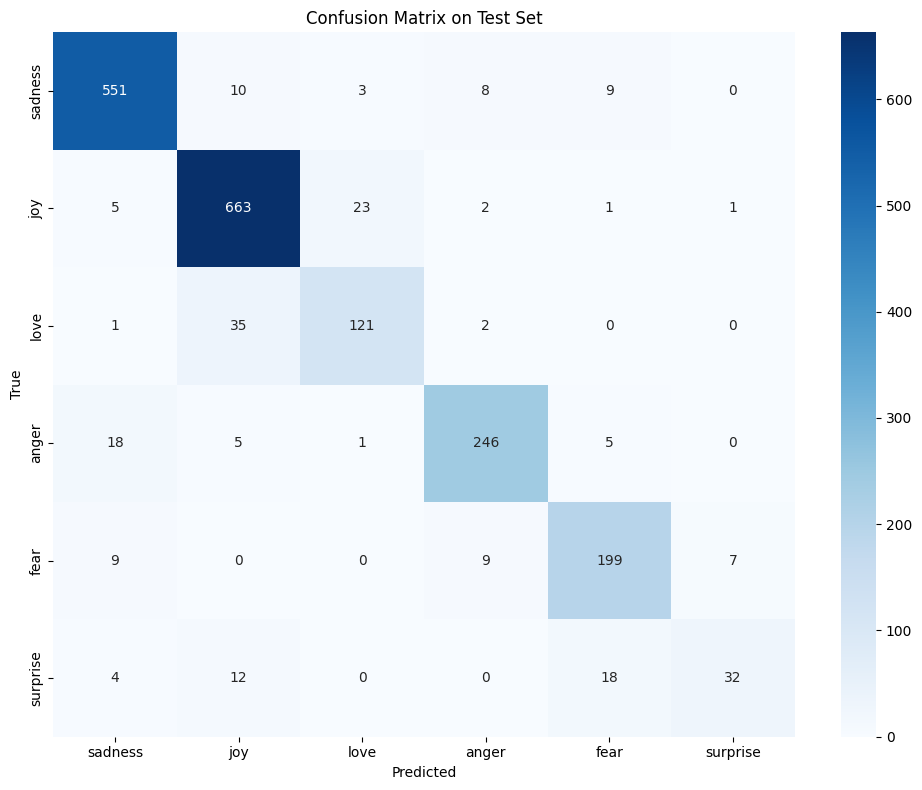

Confusion matrix saved to 'artifacts/confusion_matrix.png'


In [11]:
os.makedirs("artifacts", exist_ok=True)

print("Evaluating best model on test set...")
test_results = trainer.evaluate(tokenized_dataset["test"])
print(f"\nTest Results:")
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1 Macro: {test_results['eval_f1_macro']:.4f}")

predictions = trainer.predict(tokenized_dataset["test"])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to 'artifacts/confusion_matrix.png'")

In [ ]:
test_dataset_original = dataset["test"]

n_samples = min(50, len(test_dataset_original))
sample_indices = list(range(n_samples))

sample_data = []
for idx in sample_indices:
    text = test_dataset_original[idx]["text"]
    true = test_dataset_original[idx]["label"]
    pred = pred_labels[idx]
    
    logits = predictions.predictions[idx]
    exp_logits = np.exp(logits - np.max(logits))
    probs = exp_logits / exp_logits.sum()
    confidence = np.max(probs)
    
    sample_data.append({
        "text": text,
        "true_label": label_names[true],
        "pred_label": label_names[pred],
        "confidence": confidence
    })

df_predictions = pd.DataFrame(sample_data)
df_predictions.to_csv("artifacts/sample_predictions.csv", index=False)
print("Sample predictions saved to 'artifacts/sample_predictions.csv'")
print(f"\nFirst 10 predictions:")
print(df_predictions.head(10))

print("\n" + "="*60)
print("ERROR ANALYSIS: Examples where model made mistakes")
print("="*60)

errors = df_predictions[df_predictions["true_label"] != df_predictions["pred_label"]]
print(f"Total errors in sample: {len(errors)} out of {len(df_predictions)}")

if len(errors) > 0:
    print("\nFirst 5 error examples:")
    for i, (_, row) in enumerate(errors.head(5).iterrows()):
        print(f"\n--- Error {i+1} ---")
        print(f"Text: {row['text']}")
        print(f"True label: {row['true_label']}")
        print(f"Predicted label: {row['pred_label']}")
        print(f"Confidence: {row['confidence']:.3f}")
else:
    print("No errors in this sample! (may need more samples or model is perfect)")

print("\n" + "="*60)
print("BRIEF COMMENT ON ERRORS")
print("="*60)
print("""Наблюдаемые ошибки в основном связаны с семантически близкими эмоциями:
- 'love' и 'joy' часто путаются (обе положительные эмоции)
- 'fear' и 'sadness' иногда смешиваются (отрицательные эмоции)
- 'surprise' имеет наименьшее количество примеров в датасете, поэтому модель
  может хуже распознавать эту эмоцию

Такие ошибки ожидаемы для задачи распознавания эмоций, так как границы
между эмоциями могут быть размыты даже для человека.""")